# Bài 2: Hồi quy logistic


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split

%matplotlib inline


def sigmoid(z):
    """Ep mot so thuc bat ky ve khoang tu 0 toi 1."""
    return 1 / (1 + np.exp(-z))


def chia_du_lieu(df, cot=("gio_on",)):
    """Chia 75/25, giu nguyen random_state=17 va stratify=y nhu tai lieu."""
    X = df[list(cot)]
    y = df["qua_mon"]
    return train_test_split(X, y, test_size=0.25, random_state=17, stratify=y)


df = pd.read_csv("data/sinh_vien.csv")
df.head()

,gio_on,diem_giua_ky,qua_mon
0,5.5,3.0,0
1,19.0,6.0,1
2,14.0,7.7,0
3,11.0,3.1,0
4,10.5,5.8,1


## Bài tập 1: Thống kê theo nhóm

In [2]:
nhom_cao = df[df["diem_giua_ky"] >= 7]      # diem giua ky tu 7 tro len
nhom_con_lai = df[df["diem_giua_ky"] < 7]   # nhom con lai

so_ban_cao = len(nhom_cao)
ty_le_cao = nhom_cao["qua_mon"].mean()
ty_le_con_lai = nhom_con_lai["qua_mon"].mean()

print(f"So ban co diem giua ky >= 7      : {so_ban_cao}")
print(f"Ty le qua mon cua nhom do        : {ty_le_cao:.4f}")
print(f"Ty le qua mon cua nhom con lai   : {ty_le_con_lai:.4f}")

So ban co diem giua ky >= 7      : 31
Ty le qua mon cua nhom do        : 0.9032
Ty le qua mon cua nhom con lai   : 0.4831


## Bài tập 2: Vẽ hàm sigmoid


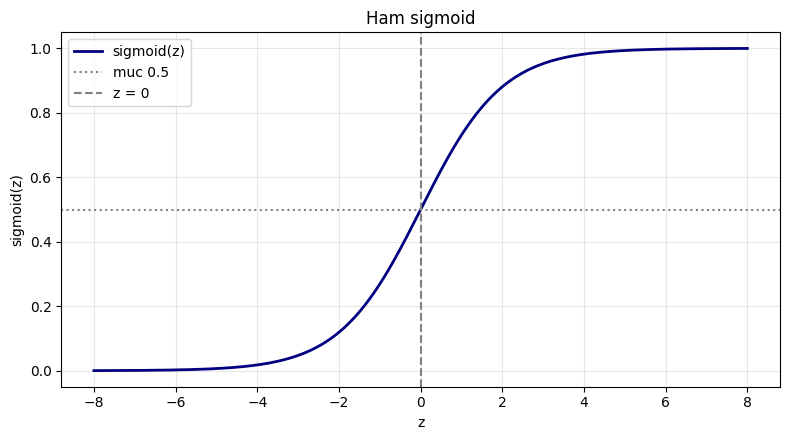

Da luu do thi vao tep sigmoid.png


In [3]:
z = np.linspace(-8, 8, 400)

plt.figure(figsize=(8, 4.5))
plt.plot(z, sigmoid(z), color="navy", linewidth=2, label="sigmoid(z)")
plt.axhline(0.5, color="gray", linestyle=":", label="muc 0.5")
plt.axvline(0, color="gray", linestyle="--", label="z = 0")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Ham sigmoid")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("sigmoid.png", dpi=150)   # luu ra thu muc goc
plt.show()

print("Da luu do thi vao tep sigmoid.png")

## Bài tập 3: Dự đoán cho một bạn cụ thể


In [4]:
mo_hinh = LogisticRegression().fit(df[["gio_on"]], df["qua_mon"])
w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])


def du_doan(gio):
    """In ra z, xac suat qua mon va nhan theo nguong 0.5."""
    z = w * gio + b
    xac_suat = sigmoid(z)
    nhan = 1 if xac_suat >= 0.5 else 0
    print(f"  {gio:6.2f} gio:  z = {z:+.4f}   xac suat qua = {xac_suat:.4f}   nhan = {nhan}")


print(f"Mo hinh: w = {w:.6f}, b = {b:.6f}")
print("Du doan:")
for gio in [3, 8, 12.89, 18, 26]:
    du_doan(gio)

Mo hinh: w = 0.392819, b = -5.064890
Du doan:
    3.00 gio:  z = -3.8864   xac suat qua = 0.0201   nhan = 0
    8.00 gio:  z = -1.9223   xac suat qua = 0.1276   nhan = 0
   12.89 gio:  z = -0.0015   xac suat qua = 0.4996   nhan = 0
   18.00 gio:  z = +2.0059   xac suat qua = 0.8814   nhan = 1
   26.00 gio:  z = +5.1484   xac suat qua = 0.9942   nhan = 1


## Bài tập 4: Tự tính bốn thước đo

In [5]:
X_train, X_test, y_train, y_test = chia_du_lieu(df)

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

# Chi dung confusion_matrix de lay bon so, con bon thuoc do tu tinh
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
n = tn + fp + fn + tp

accuracy = (tp + tn) / n
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
if precision + recall > 0:
    f1 = 2 * precision * recall / (precision + recall)
else:
    f1 = 0.0

print(f"TP = {tp}, TN = {tn}, FP = {fp}, FN = {fn}")
print()
print("Tu tinh:")
print(f"  Accuracy  = ({tp} + {tn}) / {n} = {accuracy:.4f}")
print(f"  Precision = {tp} / ({tp} + {fp}) = {precision:.4f}")
print(f"  Recall    = {tp} / ({tp} + {fn}) = {recall:.4f}")
print(f"  F1        = 2 * {precision:.4f} * {recall:.4f} / ({precision:.4f} + {recall:.4f}) = {f1:.4f}")
print()

# Doi chieu voi thu vien (chi de kiem tra, khong dung de tinh)
khop = (
    np.isclose(accuracy, accuracy_score(y_test, y_pred))
    and np.isclose(precision, precision_score(y_test, y_pred))
    and np.isclose(recall, recall_score(y_test, y_pred))
    and np.isclose(f1, f1_score(y_test, y_pred))
)
print("Doi chieu voi scikit-learn:", "KHOP" if khop else "LECH, kiem tra lai cong thuc")

TP = 17, TN = 9, FP = 3, FN = 1

Tu tinh:
  Accuracy  = (17 + 9) / 30 = 0.8667
  Precision = 17 / (17 + 3) = 0.8500
  Recall    = 17 / (17 + 1) = 0.9444
  F1        = 2 * 0.8500 * 0.9444 / (0.8500 + 0.9444) = 0.8947

Doi chieu voi scikit-learn: KHOP


**Giải thích:**
- **Accuracy** đếm cả hai ô đúng ($TP + TN$) trên tổng số bạn.
- **Precision** chia cho *những gì mô hình nói* ($TP + FP$): trong 20 bạn được báo sẽ qua, 17 bạn qua thật.
- **Recall** chia cho *những gì có thật* ($TP + FN$): trong 18 bạn thật sự qua, mô hình tìm ra 17 bạn.
- **F1** là trung bình điều hòa của precision và recall, gộp hai số lại cho tiện so sánh.

## Bài tập 5: Dò ngưỡng tốt nhất theo F1


In [6]:
X_train, X_test, y_train, y_test = chia_du_lieu(df)

mo_hinh = LogisticRegression().fit(X_train, y_train)
p = mo_hinh.predict_proba(X_test)[:, 1]

print("Nguong   F1")
ket_qua = []
for nguong in np.arange(0.05, 1.0, 0.05):
    y_pred = (p >= nguong).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    ket_qua.append((nguong, f1))
    print(f"  {nguong:.2f}   {f1:.4f}")
print()

nguong_tot, f1_tot = max(ket_qua, key=lambda cap: cap[1])
print(f"Nguong cho F1 cao nhat: {nguong_tot:.2f} (F1 = {f1_tot:.4f})")

Nguong   F1


  0.05   0.7826
  0.10   0.8182
  0.15   0.8182
  0.20   0.8571
  0.25   0.9000
  0.30   0.8947
  0.35   0.8947
  0.40   0.8947
  0.45   0.8947
  0.50   0.8947
  0.55   0.8889
  0.60   0.9412
  0.65   0.9412
  0.70   0.9091
  0.75   0.8750
  0.80   0.8387
  0.85   0.8000
  0.90   0.5600
  0.95   0.4348

Nguong cho F1 cao nhat: 0.60 (F1 = 0.9412)


## Bài tập 6: Đổi lớp dương rồi chấm lại

In [7]:
X_train, X_test, y_train, y_test = chia_du_lieu(df)

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

pre_1 = precision_score(y_test, y_pred, pos_label=1)
rec_1 = recall_score(y_test, y_pred, pos_label=1)
pre_0 = precision_score(y_test, y_pred, pos_label=0)
rec_0 = recall_score(y_test, y_pred, pos_label=0)

print("Lop duong = qua mon (lop 1):")
print(f"  Precision = {pre_1:.4f}")
print(f"  Recall    = {rec_1:.4f}")
print()
print("Lop duong = rot mon (lop 0):")
print(f"  Precision = {pre_0:.4f}")
print(f"  Recall    = {rec_0:.4f}")
print()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"Lop 1 la duong: precision = {tp}/({tp}+{fp}), recall = {tp}/({tp}+{fn})")
print(f"Lop 0 la duong: precision = {tn}/({tn}+{fn}), recall = {tn}/({tn}+{fp})")

Lop duong = qua mon (lop 1):
  Precision = 0.8500
  Recall    = 0.9444

Lop duong = rot mon (lop 0):
  Precision = 0.9000
  Recall    = 0.7500

Lop 1 la duong: precision = 17/(17+3), recall = 17/(17+1)
Lop 0 la duong: precision = 9/(9+1), recall = 9/(9+3)
